In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# 모델 설정
model_name = "google/gemma-4-E2B-it"
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Loading model on {device}...")

# 모델 로드 (최적화됨)
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)
model.eval()

# BOS 토큰 설정
tokenizer.add_bos_token = True

print("Model loaded successfully!")
print(f"BOS token: {tokenizer.bos_token_id}, EOS token: {tokenizer.eos_token_id}")

def generate(prompt: str, max_tokens: int = 256, temperature: float = 0.7, top_p: float = 0.9):
    """텍스트 생성 함수"""
    # 프롬프트 준비
    full_prompt = f"<bos>{prompt}"  # BOS 토큰 명시적 추가
    
    inputs = tokenizer(full_prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            temperature=temperature,
            top_p=top_p,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.2,  # 반복 제약
            no_repeat_ngram_size=2,  # 2-gram 반복 금지
            length_penalty=1.0
        )
    
    # 입력 토큰만 제거하고 생성된 텍스트만 반환
    generated_ids = outputs[0][inputs.input_ids.shape[-1]:]
    generated_text = tokenizer.decode(generated_ids, skip_special_tokens=True)
    
    
    return generated_text.strip()


Loading model on cuda...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/1951 [00:00<?, ?it/s]

Model loaded successfully!
BOS token: 2, EOS token: 1


In [2]:
# make_prompt 함수 정의
def make_prompt(behavior_summary: str) -> str:
    prompt = f"""Convert the following ego vehicle behavior summary into a short driving instruction for a Vision Language Agent (VLA). 
The instruction should be concise and direct, starting with an action verb.
Output only the instruction without any additional explanation or context.
example: "Ego vehicle 0 continues straight forward along its visible future trajectory." -> "Go straight forward."
Behavior summary: {behavior_summary}
Driving instruction:"""
    return prompt

In [ ]:
import jsonlines
import json
from collections import OrderedDict
from tqdm import tqdm
with open("/zfsauton/scratch/eshau/query_waymax_outputs/gemma4_waymax_structured_best_50k_merged.jsonl") as f:
    data = list(jsonlines.Reader(f))
file_path = "/zfsauton/scratch/mineuih/waymax_rs/gemma4_50k_merged_instructions.jsonl"
with open(file_path, "w", encoding="utf-8") as f:
    for item in tqdm(data):
        # print(item)
        # print(item['image_path'])
        image_path = item['image_path'].split("/")[-1]
        tfrecord = int(image_path.split("_")[1])
        scenario = int(image_path.split("_")[3])
        start = int(image_path.split("_")[5])
        traj_summary = item['parsed']['trajectory_summary']
        prompt = make_prompt(traj_summary)
        generated_instruction = generate(prompt)
        result = OrderedDict({
            "tfrecord": tfrecord,
            "scenario": scenario,
            "start": start,
            "summary": traj_summary,
            "instruction": generated_instruction
        })
        json.dump(result, f, ensure_ascii=False)
        f.write("\n")
        # print(f"Trajectory summary: {traj_summary}")
        # print(f"Generated instruction: {generated_instruction}\n")


PermissionError: [Errno 13] Permission denied: '/zfsauton/scratch/eshau/query_waymax_outputs/gemma4_50k_merged_instructions.jsonl'

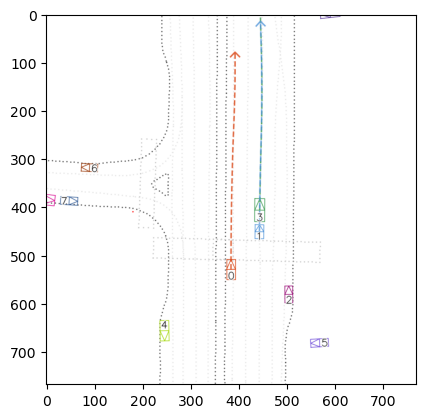

Ego vehicle 0 travels forward in a straight line.
Go straight ahead.


In [3]:
import jsonlines
import json
from collections import OrderedDict
from tqdm import tqdm
import matplotlib.pyplot as plt
with open("/zfsauton/scratch/eshau/query_waymax_outputs/gemma4_waymax_structured_best_50k_merged.jsonl") as f:
    data = list(jsonlines.Reader(f))
file_path = "/zfsauton/scratch/mineuih/waymax_rs/gemma4_50k_merged_instructions.jsonl"
for index, item in enumerate(data):
    image_path = item['image_path']
    image_path = "/zfsauton/scratch/eshau/" + image_path
    plt.figure()
    plt.imshow(plt.imread(image_path))
    plt.show()
    print(item['parsed']['trajectory_summary'])
    with open(file_path) as f:
        instructions = list(jsonlines.Reader(f))
    print(instructions[index]['instruction'])
    break

    tfrecord = int(image_path.split("_")[1])
    scenario = int(image_path.split("_")[3])
    start = int(image_path.split("_")[5])
    traj_summary = item['parsed']['trajectory_summary']
    prompt = make_prompt(traj_summary)
    generated_instruction = generate(prompt)
    result = OrderedDict({
        "tfrecord": tfrecord,
        "scenario": scenario,
        "start": start,
        "summary": traj_summary,
        "instruction": generated_instruction
    })
    with open(file_path, "a", encoding="utf-8") as f:  # 'a' 모드로 파일 열기
        json.dump(result, f, ensure_ascii=False)
        f.write("\n")